# 样章 · 用 Python 表达积累与清除

## 学习目标与先修知识

完成后，你能写出递推关系（recurrence relation）和更新循环，区分状态（state）、参数（parameter）与时间步长（time step），并用逐步收支（mass balance）核验计算结果。

**先修知识**：[系统边界、变量与单位](01-boundaries-units.ipynb)中的速率、持续时间与收支关系。


## 具体问题

上一节给定了清除速率。现在提出机制假设：室内物质越多，每单位时间清除的也越多。
用 kA 表达这个比例关系。若 k = 0.5 /T、当前 A = 2 U，清除速率便是 1 U/T。

## 初步实验

取 A₀ = 0 U，u = 1 U/T，k = 0.5 /T，h = 0.1 T。
第一步末有 0.1 U，第二步清除速率升到 0.05 U/T，新增量便小于第一步。

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
from systems_science.theme import DATA_COLORS, SERIES_COLORS

plot_style()

In [2]:
A0, u, k, h = 0.0, 1.0, 0.5, 0.1
first_three = [A0]
for _ in range(3):
    first_three.append(first_three[-1] + h * (u - k * first_three[-1]))
print(first_three)
assert np.allclose(first_three, [0.0, 0.1, 0.195, 0.28525])

[0.0, 0.1, 0.195, 0.28525]


## 模型假设

把研究对象看成一个**充分混合的单室模型（one-compartment model）**：用一个数描述室内示踪物质（tracer）总量。
示踪物质只是便于思考的标记物。本单元使用人工单位 U 与 T，参数是教学选择，
不对应具体药物、患者或真实生理测量。边界外的输入被视为已知；不讨论组织容积、
浓度（concentration）、多室交换或观测噪声。A 是物质量，不是浓度。

| 量 | 含义 | 单位与条件 |
|---|---|---|
| $t$ | 从实验起点经过的时间 | T，$t\geq0$ |
| $A$、$A_0$ | 当前与初始物质量 | U，连续模型非负 |
| $u$ | 流入速率 | U/T，非负 |
| $k$ | 比例清除系数（elimination rate constant） | 1/T，非负 |
| $h$ | 计算时间步长 | T，正数 |

假设清除速率为 $kA$，单位是 U/T。这个比例关系是一项建模假设，
不代表所有物质在任意条件下都按同一机制清除。

## 数学解释与推导

令 $t_n=nh$，$A_n$ 为此刻的近似存量（stock）。用区间起点的流率代表整个小区间：

$$\text{流入量}=hu,\quad\text{清除量}=hkA_n,$$
$$A_{n+1}=A_n+h(u-kA_n).$$

这是一条递推关系：给出初值（initial condition），就能逐步算后面的状态。
其有限累积形式为 $A_N-A_0=\sum_{n=0}^{N-1}h(u-kA_n)$，符号 Σ 表示把各步相加。
清除速率实际上可能在区间内变化，所以“冻结起点流率”是数值近似，精度留到 S05 检查。

k 的单位是 1/T，kh 才是无单位的“本步清除比例”。改变 h 只是改变计算分辨率，
不能同时把 k 当成每步不变的比例。

## 核心实现

`np.linspace` 构造从 0 到观察终点的一串时刻；`np.empty` 预留存量数组，
随后初值和循环填满每个位置。每次使用实际相邻时刻之差计算收支。
函数在本节显式定义，后面的参数实验重复调用同一循环。

In [3]:
def euler(u=1.0, k=0.5, A0=0.0, h=0.1, duration=20.0):
    """恒定输入下的显式 Euler；保留负值以识别数值失败。"""
    if not all(np.isfinite(v) for v in (u, k, A0, h, duration)):
        raise ValueError("参数必须是有限数")
    if min(u, k, A0) < 0 or h <= 0 or duration <= 0:
        raise ValueError("输入、清除和初值非负，步长与时长为正")
    n_steps = round(duration / h)
    if n_steps < 1 or not np.isclose(n_steps * h, duration, rtol=0, atol=1e-10):
        raise ValueError("本节要求步长整除观察时长；分段步长见 S06")
    times = np.linspace(0.0, duration, n_steps + 1)
    amounts = np.empty(n_steps + 1)
    amounts[0] = A0
    for n in range(n_steps):
        dt = times[n + 1] - times[n]
        inflow = u * dt
        outflow = k * amounts[n] * dt
        amounts[n + 1] = amounts[n] + inflow - outflow
    if not np.all(np.isfinite(amounts)):
        raise FloatingPointError("数值结果非有限，请检查步长")
    return times, amounts

In [4]:
times, amounts = euler()
steps = np.diff(times)
balance_residual = np.diff(amounts) - steps * (u - k * amounts[:-1])
assert np.max(np.abs(balance_residual)) < 1e-10
assert np.allclose(amounts[:4], first_three)
rows = [[times[n], amounts[n], steps[n] * u, steps[n] * k * amounts[n], amounts[n+1]] for n in range(3)]
display(Markdown(show_table(["起点 / T", "存量 / U", "进入 / U", "清除 / U", "终点 / U"], rows)))
print(f"最大逐步收支残差：{np.max(np.abs(balance_residual)):.3g} U")

| 起点 / T | 存量 / U | 进入 / U | 清除 / U | 终点 / U |
| --- | --- | --- | --- | --- |
| 0 | 0 | 0.1 | 0 | 0.1 |
| 0.1 | 0.1 | 0.1 | 0.005 | 0.195 |
| 0.2 | 0.195 | 0.1 | 0.00975 | 0.28525 |

最大逐步收支残差：3.16e-16 U


## 对照实验

每张小图只改变一个条件：流入 u、清除系数 k 或初值 A₀。其余参数采用默认值，h 固定为 0.1 T。
先预测哪条曲线的起点会变，再运行。

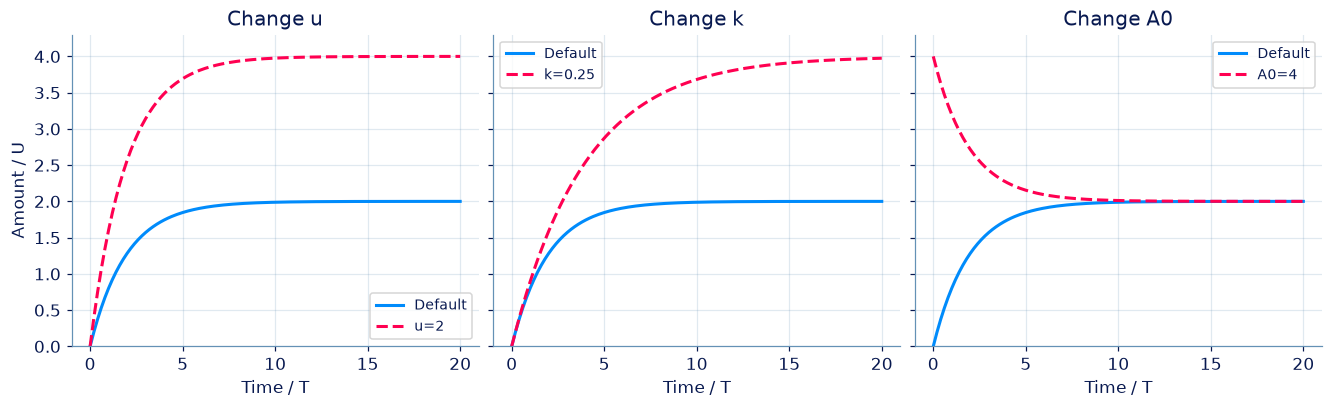

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True)
for ax, parameter, value in zip(axes, ["u", "k", "A0"], [2.0, 0.25, 4.0]):
    t0, base = euler()
    t1, changed = euler(**{parameter: value})
    ax.plot(t0, base, label="Default")
    ax.plot(t1, changed, "--", label=f"{parameter}={value:g}")
    ax.set(xlabel="Time / T", title=f"Change {parameter}", ylim=(0, 4.3))
    ax.legend(fontsize=9)
axes[0].set_ylabel("Amount / U")
plt.show()
zero_t, zero_a = euler(u=0, k=0, A0=3)
assert np.all(zero_a == 3)

## 结果解释

提高 u 使每步进入更多；减小 k 使给定存量的清除更慢；改变 A₀ 直接改变起点。
默认存量先快后慢地增长。收支残差（residual）接近机器舍入误差（round-off error），只说明程序忠实执行了递推式，
还不能证明这条近似轨迹足够接近连续模型。下一节解释曲线为何靠近某个水平。

## 练习与参考资料

先独立作答，再提交核对。每道题的题面和输入输出示例如下。

### 第 1 题 · 单项选择题：清除系数和每步比例

清除系数（elimination rate constant） k 的单位为 1/T。k = 0.5 /T 时，时间步长（time step）h = 0.1 T 与 h = 1 T 对应的 kh 分别是多少？

- **A.** 0.05 和 0.5
- **B.** 0.5 和 0.5
- **C.** 5 和 0.5
- **D.** 0.05 /T 和 0.5 /T

[作答：清除系数和每步比例](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=clearance-coefficient)

### 第 2 题 · Python 计算题：写出逐步更新循环

按递推关系（recurrence relation）A_next = A + h(u − kA) 计算恒定输入、按存量（stock）比例清除的轨迹。

**函数与代码模板**

```python
def solve(
    u: float,
    k: float,
    A0: float,
    h: float,
    steps: int,
) -> list[float]:
    # 返回 amounts 列表。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `u` | `float` | 每单位时间流入的物质量，整个计算期间不变。 | U/T |
| `k` | `float` | 清除系数（elimination rate constant）；物质量为 A 时，清除流率为 k·A。 | 1/T |
| `A0` | `float` | 计算开始时的物质量。 | U |
| `h` | `float` | 每次更新跨过的时间间隔。 | T |
| `steps` | `int` | 从初始时刻出发，需要执行的更新次数。 | 步 |

**返回值**

直接返回 amounts（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `amounts` | `list[float]` | 包含 A0 和随后 steps 次更新结果，按时间顺序排列。 | U |

**计算规则**

从 A=A0 开始，每次使用当前 A 计算 A_next = A + h·(u−k·A)，再将 A 替换为 A_next。重复 steps 次，返回整条轨迹。

**约束与边界**

- 0 ≤ u、A0 ≤ 100，0 ≤ k ≤ 1，0 < h ≤ 5；steps 是 1 到 100 的整数。
- 返回列表长度为 steps+1，第一项为初值（initial condition）A0。
- k=0 时仍按同一更新式计算；大步长产生负值时保留负值。

**输入样例**

以下是一组传给 solve 的参数；U、T 分别是物质量与时间单位。每个参数直接对应上方函数签名中的同名变量。

给定条件

| 量的含义 | 函数参数 | 给定值 | 单位 |
| --- | --- | --- | --- |
| 恒定流入速率 | u | 1 | U/T |
| 清除系数 | k | 0.5 | 1/T |
| 初始物质量 | A0 | 0 | U |
| 时间步长 | h | 0.1 | T |
| 更新步数 | steps | 3 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
u = 1
k = 0.5
A0 = 0
h = 0.1
steps = 3

result = solve(u, k, A0, h, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

包含起点与每一步更新结果

| 更新次数 | 物质量 amounts / U |
| --- | --- |
| 0 | 0 |
| 1 | 0.1 |
| 2 | 0.195 |
| 3 | 0.28525 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0, 0.1, 0.195, 0.28525]
```

**样例解释**

从 0 U 开始：第一步 0+0.1×(1−0.5×0)=0.1；第二步得到 0.195；第三步得到 0.28525。返回列表的第一项仍是起点 0。

数值核验允许绝对误差 1e-08 或相对误差 1e-07；允许使用 Python 标准库。

[作答：写出逐步更新循环](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=update-loop)

### 第 3 题 · 单项选择题：恒定流出假设的适用边界

初始存量（stock） A0=0.1 U，无输入，恒定流出 1 U/T，h=0.2 T。一步得到 −0.1 U。哪项判断恰当？

- **A.** 负值说明恒定流出假设在物质耗尽后需要重审
- **B.** 把负值裁为零后，可继续声称模型完全没变
- **C.** 只要程序没有报错，负物质量就是可信预测
- **D.** 这种现象证明所有收支（mass balance）模型都不可用

[作答：恒定流出假设的适用边界](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=constant-outflow-limits)

**进一步阅读**：[MIT 系统动力学课程](https://ocw.mit.edu/courses/15-871-introduction-to-system-dynamics-fall-2013/pages/syllabus/)；数值误差见本单元 S05。本节讲解、推导组织和代码为本项目编写。

[下一节：平衡、负反馈与参数变化](03-equilibrium-feedback.ipynb) · [单元目录](README.md)


[观察存量与流量](http://127.0.0.1:8000/samples/accumulation-clearance/explore/#stock-flow) · [比较步长与数值误差](http://127.0.0.1:8000/samples/accumulation-clearance/explore/#step-size) · [学习指南](../../../docs/学习指南.md)
